In [1]:

# Load the Dataset

import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw/nih_sample")

labels_path = DATA_DIR / "sample_labels.csv"

df = pd.read_csv(labels_path)

df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [2]:

# Dataset Size

print("Total images:", len(df))


Total images: 5606


In [3]:

# Check Label Format

df["Finding Labels"].unique()[:10]


<StringArray>
['Emphysema|Infiltration|Pleural_Thickening|Pneumothorax',
                                 'Cardiomegaly|Emphysema',
                                             'No Finding',
                                            'Atelectasis',
                            'Cardiomegaly|Edema|Effusion',
                                     'Consolidation|Mass',
                                               'Effusion',
             'Consolidation|Effusion|Infiltration|Nodule',
                                                   'Mass',
                                      'Mass|Pneumothorax']
Length: 10, dtype: str

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

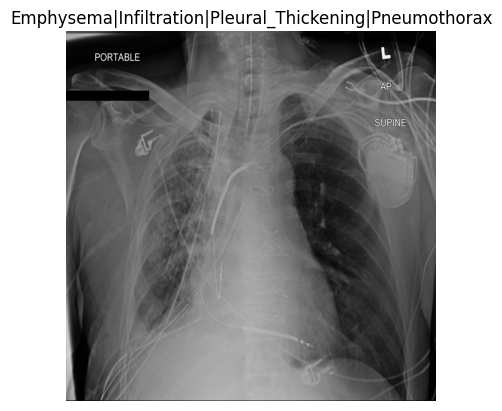

In [4]:

# Visualize Some Images

import matplotlib.pyplot as plt
from PIL import Image

image_dir = DATA_DIR / "images"

sample_image = image_dir / df.iloc[0]["Image Index"]

img = Image.open(sample_image)

plt.imshow(img, cmap="gray")
plt.title(df.iloc[0]["Finding Labels"])
plt.axis("off")


In [6]:

# Extract All Disease Classes

# Extract unique diseases

all_labels = df["Finding Labels"].str.split("|").explode().unique()

all_labels


<StringArray>
[         'Emphysema',       'Infiltration', 'Pleural_Thickening',
       'Pneumothorax',       'Cardiomegaly',         'No Finding',
        'Atelectasis',              'Edema',           'Effusion',
      'Consolidation',               'Mass',             'Nodule',
           'Fibrosis',          'Pneumonia',             'Hernia']
Length: 15, dtype: str

In [7]:

# Define Disease List

diseases = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

print("Total diseases:", len(diseases))


Total diseases: 14


In [8]:

# Create Multi-Label Encoding Function

def encode_labels(label_string):
    
    labels = label_string.split("|")
    
    encoded = [0]*len(diseases)
    
    for i, disease in enumerate(diseases):
        if disease in labels:
            encoded[i] = 1
            
    return encoded
    

In [9]:

# Apply Encoding

df["encoded_labels"] = df["Finding Labels"].apply(encode_labels)

df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,encoded_labels
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139,"[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]"
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"


In [10]:

# Verify Encoding

df[["Finding Labels","encoded_labels"]].head(10)


,Finding Labels,encoded_labels
0,Emphysema|Infiltration|Pleural_Thickening|Pneu...,"[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]"
1,Cardiomegaly|Emphysema,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"
2,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,Atelectasis,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,Cardiomegaly|Edema|Effusion,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
5,Consolidation|Mass,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
6,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
7,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
8,Effusion,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
9,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [11]:

# Analyze Disease Distribution

import numpy as np

label_matrix = np.array(df["encoded_labels"].tolist())

disease_counts = label_matrix.sum(axis=0)

for disease, count in zip(diseases, disease_counts):
    print(f"{disease}: {count}")
    

Atelectasis: 508
Cardiomegaly: 141
Effusion: 644
Infiltration: 967
Mass: 284
Nodule: 313
Pneumonia: 62
Pneumothorax: 271
Consolidation: 226
Edema: 118
Emphysema: 127
Fibrosis: 84
Pleural_Thickening: 176
Hernia: 13


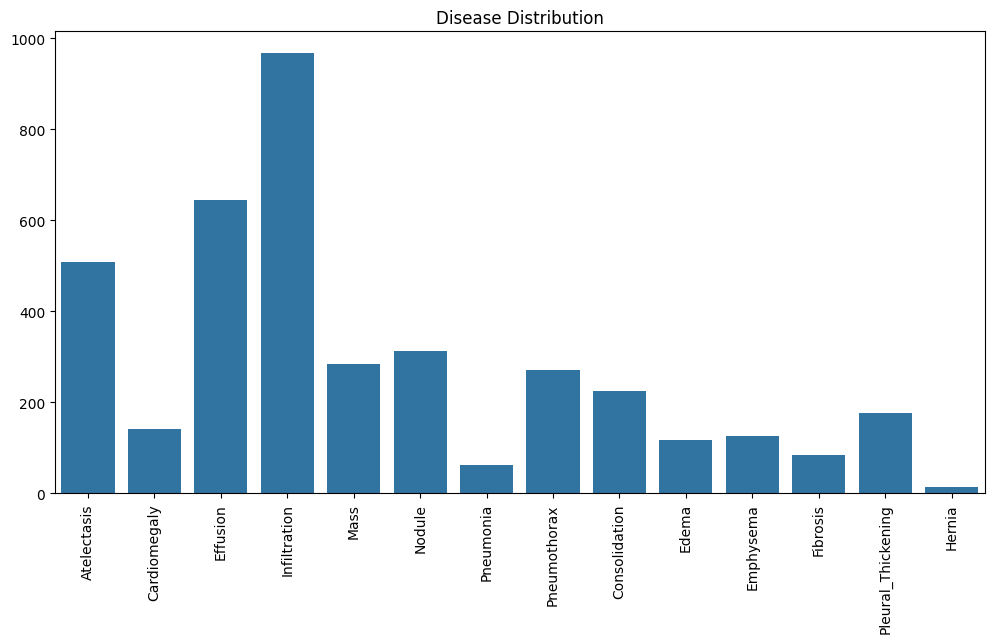

In [12]:

# Then visualize it

import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=diseases, y=disease_counts)

plt.xticks(rotation=90)
plt.title("Disease Distribution")
plt.show()


In [13]:

# Add Image Paths to DataFrame

image_dir = DATA_DIR / "images"

df["image_path"] = df["Image Index"].apply(lambda x: str(image_dir / x))

df.head()

# Now dataframe includes: image_path
# Example: ../data/raw/nih_sample/images/00000001_000.png


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,encoded_labels,image_path
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139,"[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]",..\data\raw\nih_sample\images\00000013_005.png
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",..\data\raw\nih_sample\images\00000013_026.png
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",..\data\raw\nih_sample\images\00000017_001.png
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",..\data\raw\nih_sample\images\00000030_001.png
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",..\data\raw\nih_sample\images\00000032_001.png


In [15]:

# Train / Validation Split

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))


Train samples: 4484
Validation samples: 1122


In [16]:

# Prepare Label Arrays

import numpy as np

train_labels = np.array(train_df["encoded_labels"].tolist())
val_labels = np.array(val_df["encoded_labels"].tolist())

train_labels.shape


(4484, 14)

In [17]:

# Prepare Image Input Pipeline

# Define Image Size

IMG_SIZE = (224,224)
BATCH_SIZE = 32


In [19]:

# Image Loading Function

import tensorflow as tf

def load_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, label


In [20]:

# Create TensorFlow Dataset

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_labels)
)


In [21]:

# Apply Image Loader

train_dataset = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)


In [22]:

# Batch + Prefetch

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [23]:

train_labels.shape


(4484, 14)

In [24]:

train_dataset


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.int64, name=None))>